In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# importing and reading the dataset
train = pd.read_csv("datasets/black_friday/train.csv")
test = pd.read_csv("datasets/black_friday/test.csv")

In [4]:
train

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,NaN,NaN,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,NaN,NaN,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,NaN,NaN,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,NaN,NaN,365


## Problem Statement

A retail company “ABC Private Limited” wants to understand the customer purchase behaviour (specifically, purchase amount) against various products of different categories. They have shared purchase summary of various customers for selected high volume products from last month. The data set also contains customer demographics (age, gender, marital status, city_type, stay_in_current_city), product details (product_id and product category) and Total purchase_amount from last month.

Now, they want to build a model to predict the purchase amount of customer against various products which will help them to create personalized offer for customers against different products.

In [5]:
# we want to understand the custormet purchase behaviour and a model that can predict the probalbility of customer purhcainsing a product

In [6]:
# when you get train and test data in any competition combine them so all the data processing that we do can be done for all the data 

# using pd.merge -> the best wat is to use pd.concat instead of pd.merge 
df = pd.concat([train, test], ignore_index=True)
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0
...,...,...,...,...,...,...,...,...,...,...,...,...
783662,1006036,P00118942,F,26-35,15,B,4+,1,8,NaN,NaN,NaN
783663,1006036,P00254642,F,26-35,15,B,4+,1,5,8.0,NaN,NaN
783664,1006036,P00031842,F,26-35,15,B,4+,1,1,5.0,12.0,NaN
783665,1006037,P00124742,F,46-50,1,C,4+,0,10,16.0,NaN,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  str    
 2   Gender                      783667 non-null  str    
 3   Age                         783667 non-null  str    
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  str    
 6   Stay_In_Current_City_Years  783667 non-null  str    
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), str(5)
memory usage: 71.7 MB


In [8]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,7.836670e+05,783667.000000,783667.000000,783667.000000,537685.000000,237858.000000,550068.000000
mean,1.003029e+06,8.079300,0.409777,5.366196,9.844506,12.668605,9263.968713
std,1.727267e+03,6.522206,0.491793,3.878160,5.089093,4.125510,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001519e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003075e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [9]:
# in the entire dataset, we can notice that user id is something not much important for use thus let's drop it
df.drop(['User_ID'], axis = 1, inplace=True)
df.head() #check

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


### how many categorical data do we have? 
we have : gender, age, occupation, city, stay_in_city 

*let's convert the categorical to numerical.. like for male and female we can use 0,1*

**Note**: Refer True and false as 1 and 0 respectively.

In [10]:
pd.get_dummies(df['Gender']).astype(int) # the kind of encoding we can use.. 
# df['Gender'] = pd.get_dummies(df['Gender'], drop_first=1) another way to implement 

#astype(int) is to convert the True false in 0 and 1's

,F,M
0,1,0
1,1,0
2,1,0
3,1,0
4,0,1
...,...,...
783662,1,0
783663,1,0
783664,1,0
783665,1,0


### Handline the categorical feature - Gender

In [11]:
df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,0,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,0,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,0,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,0,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,1,55+,16,C,4+,0,8,NaN,NaN,7969.0


### Handline the categorical feature - Age

In [12]:
df['Age'].unique()

<StringArray>
['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25']
Length: 7, dtype: str

In [13]:
pd.get_dummies(df['Age']).astype(int)
# Even though we can use this but it's not a good practice as not every group purhcaes in high amount the 0-17
# might purcahse less while 26-35 more so the model should undersatnd the improtance 
# so it might not be good idea to merge the below 7 columns into the datset 

,0-17,18-25,26-35,36-45,46-50,51-55,55+
0,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0
4,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...
783662,0,0,1,0,0,0,0
783663,0,0,1,0,0,0,0
783664,0,0,1,0,0,0,0
783665,0,0,0,0,1,0,0


In [14]:
# This is called Target guiding or Target ordinal Encoding even label encoding would work (serach it): Our ML model will automatically understand don't worry
targets = {
    '0-17': 1,
    '18-25': 2,
    '26-35': 3,
    '36-45': 4,
    '46-50': 5,
    '51-55': 6, 
    '55+': 7
} 

df['Age'] = df['Age'].map(targets)

In [15]:
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,0,1,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,0,1,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,0,1,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,0,1,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,1,7,16,C,4+,0,8,NaN,NaN,7969.0


### Handling the categorical feature - City_category

In [16]:
# fixing categorical City_category
df_city = pd.get_dummies(df['City_Category'], drop_first=1).astype(int) #drop_first mean: if we have 3 category then 2 are sufficient to represent.. 
# we'll conbine it into our df dataset

In [17]:
df = pd.concat([df, df_city], axis=1)
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,A,2,0,3,NaN,NaN,8370.0,0,0
1,P00248942,0,1,10,A,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,A,2,0,12,NaN,NaN,1422.0,0,0
3,P00085442,0,1,10,A,2,0,12,14.0,NaN,1057.0,0,0
4,P00285442,1,7,16,C,4+,0,8,NaN,NaN,7969.0,0,1


In [18]:
df.drop(['City_Category'], axis = 1, inplace=True)
df

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,2,0,3,NaN,NaN,8370.0,0,0
1,P00248942,0,1,10,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,2,0,12,NaN,NaN,1422.0,0,0
3,P00085442,0,1,10,2,0,12,14.0,NaN,1057.0,0,0
4,P00285442,1,7,16,4+,0,8,NaN,NaN,7969.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
783662,P00118942,0,3,15,4+,1,8,NaN,NaN,NaN,1,0
783663,P00254642,0,3,15,4+,1,5,8.0,NaN,NaN,1,0
783664,P00031842,0,3,15,4+,1,1,5.0,12.0,NaN,1,0
783665,P00124742,0,5,1,4+,0,10,16.0,NaN,NaN,0,1


In [19]:
# let's check the missing vlaues
df.isna().sum()
# so as we can see, production_2 and 3 are have lots of null data and purchase too has many but it's test data we we don't need to intefier

Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            245982
Product_Category_3            545809
Purchase                      233599
B                                  0
C                                  0
dtype: int64

### Handling Missing values:
As we can see above, production_2 and 3 are have lots of null data and purchase too has many but it's test data we we don't need to interfier with it but let's do something with product_2 and 3

In [20]:
#focusing on replacing the missing values
df['Product_Category_2'].unique() # as we can see we have descrete values so the best thing to replace nan with soemthing else is - Mode!
display(df['Product_Category_2'].value_counts())

Product_Category_2
8.0     91317
14.0    78834
2.0     70498
16.0    61687
15.0    54114
5.0     37165
4.0     36705
6.0     23575
11.0    20230
17.0    19104
13.0    15054
9.0      8177
12.0     7801
10.0     4420
3.0      4123
18.0     4027
7.0       854
Name: count, dtype: int64

In [21]:
df['Product_Category_2'].mode()

0    8.0
Name: Product_Category_2, dtype: float64

In [22]:
#Replacing the missing values with mode
df['Product_Category_2'] = df['Product_Category_2'].fillna(df['Product_Category_2'].mode()[0])
# df['Product_Category_2'].describe()

In [23]:
df['Product_Category_2'].isnull().sum() # so done! let's so with other categories

np.int64(0)

In [24]:
#replacing product_3 missing values
# df['Product_Category_3'].unique()
df['Product_Category_3'] = df['Product_Category_3'].fillna(df['Product_Category_3'].mode()[0])
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,2,0,3,8.0,16.0,8370.0,0,0
1,P00248942,0,1,10,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,2,0,12,8.0,16.0,1422.0,0,0
3,P00085442,0,1,10,2,0,12,14.0,16.0,1057.0,0,0
4,P00285442,1,7,16,4+,0,8,8.0,16.0,7969.0,0,1


In [25]:
# stay_in_city category -> numerical
df['Stay_In_Current_City_Years'].unique()

<StringArray>
['2', '4+', '3', '1', '0']
Length: 5, dtype: str

In [26]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].str.replace('+', '') #thsi is really usefull direct matinuate entire dataset of a column and perform diffrent str operations
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,2,0,3,8.0,16.0,8370.0,0,0
1,P00248942,0,1,10,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,2,0,12,8.0,16.0,1422.0,0,0
3,P00085442,0,1,10,2,0,12,14.0,16.0,1057.0,0,0
4,P00285442,1,7,16,4,0,8,8.0,16.0,7969.0,0,1


In [27]:
#any more categories left? 
df.info()
#let's convert the str's to int now 

<class 'pandas.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  str    
 1   Gender                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  str    
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          783667 non-null  float64
 8   Product_Category_3          783667 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  B                           783667 non-null  int64  
 11  C                           783667 non-null  int64  
dtypes: float64(3), int64(7), str(2)
memory usage: 71.7 MB


In [28]:
# test = pd.DataFrame(['2', '4', '3', '1', '0'], columns=['Stay_In_Current_City_Years'], index=[0,1,2,3,4])
# test.info()
# test = test.astype('Int8')
# test.info()

In [29]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  str    
 1   Gender                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  int64  
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          783667 non-null  float64
 8   Product_Category_3          783667 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  B                           783667 non-null  int64  
 11  C                           783667 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 71.7 MB


### Visualization of the data so some insights.

```python
sns.pairplot(df)
```
![image.png](../assets/sample_pairplot.jpeg)

In [30]:
# best visualisation we can do is using sns
# sns.pairplot(df) # very helpful yet takes really long time so avoid or test with small sample data
# sns.pairplot(df.sample(1000))

<Axes: xlabel='Age', ylabel='Purchase'>

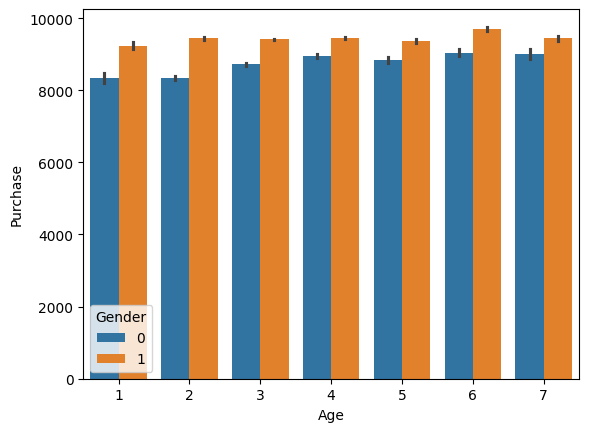

In [31]:
sns.barplot(x = 'Age', y= 'Purchase', hue = 'Gender', data=df)

### obeservations
1. Purschasing of Men is High then women although the data across the ages is uniform

<Axes: xlabel='Occupation', ylabel='Purchase'>

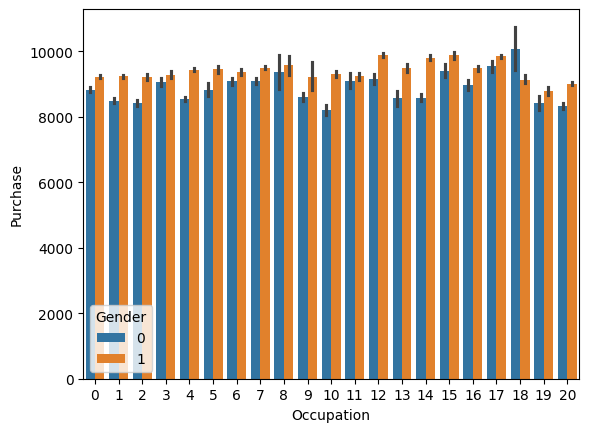

In [32]:
### viszalise purchase and occupation 

sns.barplot(x = 'Occupation', y= 'Purchase', hue = 'Gender', data=df) #it's also pretty much uniform

<Axes: xlabel='Product_Category_1', ylabel='Purchase'>

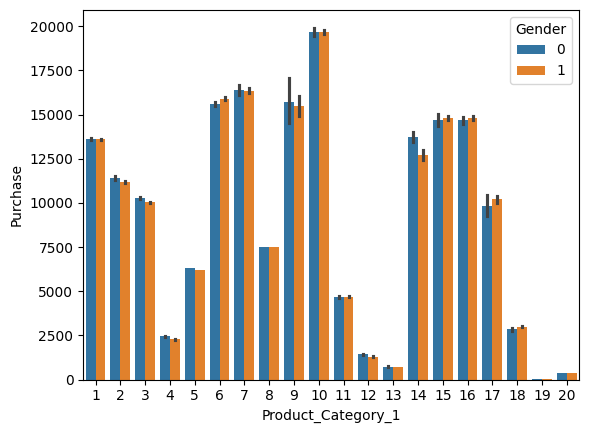

In [33]:
sns.barplot(x = 'Product_Category_1', y= 'Purchase', hue = 'Gender', data=df)

<Axes: xlabel='Product_Category_2', ylabel='Purchase'>

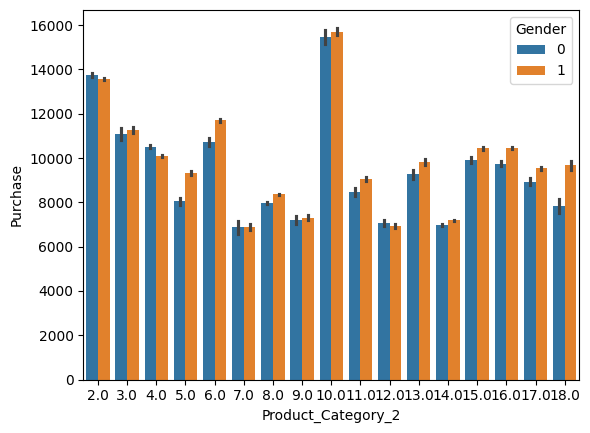

In [34]:
sns.barplot(x = 'Product_Category_2', y= 'Purchase', hue = 'Gender', data=df)

<Axes: xlabel='Product_Category_3', ylabel='Purchase'>

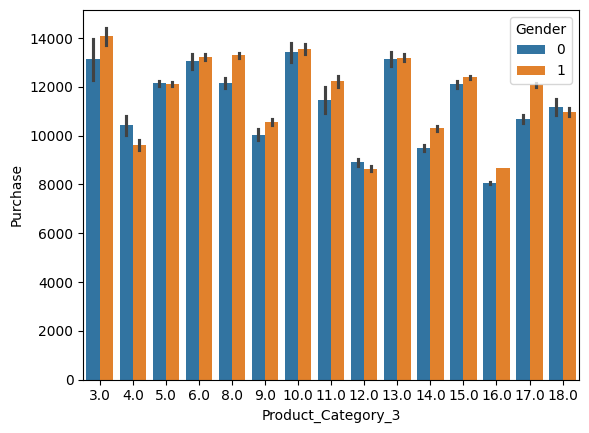

In [35]:
sns.barplot(x = 'Product_Category_3', y= 'Purchase', hue = 'Gender', data=df)

### Observatiosons : 
1. Product_Category_1 : has the higest purchase almost reaching 20000 
2. Product_Category_2 : has the second highest purchase but is more uniform 
3. Product_Category_3 : has a little less the 2 and the too is a uniform 

In [36]:
# Feature scalling 
df_test = df[df['Purchase'].isnull()] # Remeber we didn't touch this col, here we're sepating the testing and traing datas
df_train = df[~df['Purchase'].isnull()]

In [37]:
df_train.shape

(550068, 12)

## Creating the Model and Training and testing the data

In [ ]:
# we won't need product id so let's remove it 
df_train.drop(['Product_ID'], axis  = 1, inplace= True)
df_test.drop(['Product_ID'], axis  = 1, inplace= True)
df_test.head()

,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
550068,1,5,7,2,1,1,11.0,16.0,NaN,1,0
550069,1,3,17,0,0,3,5.0,16.0,NaN,0,1
550070,0,4,1,4,1,5,14.0,16.0,NaN,1,0
550071,0,4,1,4,1,4,9.0,16.0,NaN,1,0
550072,0,3,1,1,0,4,5.0,12.0,NaN,0,1


In [48]:
X = df_train.drop('Purchase', axis=1)
y = df_train['Purchase']

In [49]:
X.shape, y.shape

((550068, 10), (550068,))

In [50]:
# train and test split - google it simply (save tiem)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [51]:
X_train.shape

(368545, 10)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [53]:
# now simplily train the model!